# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [1]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=b96a1e3160d237045bc8307ade8036282c651fa5aa28854f65f5a1c095e1058d
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [2]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
stops = set(stopwords.words('spanish'))
print(stops)

{'ante', 'fueses', 'sentida', 'estarás', 'fueran', 'fue', 'el', 'te', 'suyo', 'esto', 'está', 'estos', 'seríamos', 'fueras', 'tenidas', 'fuésemos', 'estabas', 'cual', 'vuestras', 'tuviésemos', 'tienes', 'tendrías', 'haya', 'todos', 'hayáis', 'tenéis', 'estuviesen', 'sean', 'nos', 'tened', 'estás', 'habrías', 'sois', 'serás', 'esta', 'estadas', 'hubieseis', 'por', 'seamos', 'tuviera', 'erais', 'estaríais', 'teníamos', 'estarías', 'hubo', 'sin', 'eso', 'estarán', 'un', 'estarían', 'esas', 'tu', 'se', 'tenían', 'algunas', 'míos', 'estaréis', 'nuestras', 'nuestra', 'habidas', 'tengamos', 'estando', 'vuestro', 'suya', 'será', 'estabais', 'suyas', 'eras', 'pero', 'habido', 'sería', 'fuéramos', 'me', 'hubimos', 'sentidas', 'estéis', 'ya', 'tenía', 'tuviéramos', 'tuviste', 'hubieron', 'tuviesen', 'seréis', 'nada', 'estuve', 'tú', 'otros', 'tendríamos', 'quien', 'eran', 'estoy', 'nosotras', 'no', 'muy', 'serían', 'habríais', 'habría', 'le', 'con', 'quienes', 'hube', 'tengas', 'fuesen', 'otro', 

***

## <font color=#05C0F3>**Datos de comentarios de peliculas en IMDB**</font>

In [4]:
url = "https://media.githubusercontent.com/media/JhonatanO24/sentiment-api-equipo39/refs/heads/data-science/data_science/datasets/IMDB%20Dataset%20SPANISH.csv"
datos = pd.read_csv(url)

In [5]:
datos = datos[['review_es', 'sentimiento']]

In [6]:
display(datos)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo


***

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [7]:
datos.head(10)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
5,Probablemente mi película favorita de todos lo...,positivo
6,Seguro que me gustaría ver una resurrección de...,positivo
7,"Este espectáculo fue una idea increíble, fresc...",negativo
8,Alentados por los comentarios positivos sobre ...,negativo
9,"Si te gusta la risa original desgarradora, te ...",positivo


In [8]:
datos.tail(10)

,review_es,sentimiento
49990,"Cojo, cojo, cojo !!!Un festival de 90 minutos ...",negativo
49991,"Les Visiteurs, la primera película sobre los v...",negativo
49992,John Garfield interpreta a un marine que está ...,positivo
49993,Robert Colomb tiene dos trabajos a tiempo comp...,negativo
49994,Esta es tu comedia de chatarra típica. Casi no...,negativo
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo
49999,Nadie espera que las películas de Star Trek se...,negativo


In [9]:
datos.sample(10)

,review_es,sentimiento
18665,Estoy Bout It (1997) Desarrollado y publicado ...,negativo
31245,Esta película es una visita obligada para cual...,positivo
46630,SAPS en la relación de aspecto de mar: 1.37: 1...,negativo
19883,"Son solo historias, algunas nos sucedieron a n...",positivo
25164,"Otra película ""debe tener"".Henry Brandon es un...",positivo
1658,"Sí, sé que esta película está destinada a una ...",positivo
28761,"Entré en la historia recta, esperando un trist...",positivo
31768,Una de las muchas especulaciones sobre el Y2K ...,positivo
38702,"Grim en lugar de divertirse, enérgico en lugar...",negativo
31250,"Gene Kelly, Frank Sinatra, Kathryn Grayson, y ...",positivo


### **Verificación de Dimensiones y Tipos**

In [10]:
print(f'Los datos tienen {datos.shape[0]} filas y {datos.shape[1]} columnas.')

Los datos tienen 50000 filas y 2 columnas.


In [11]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_es    50000 non-null  object
 1   sentimiento  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **Eliminando duplicados**

In [12]:
datos.shape

(50000, 2)

In [13]:
datos = datos.drop_duplicates()

In [14]:
datos.shape

(49599, 2)

Se eliminan 401 duplicados

### **Longitud de los textos**

In [15]:
datos.describe()

,review_es,sentimiento
count,49599,49599
unique,49599,2
top,Nadie espera que las películas de Star Trek se...,positivo
freq,1,24886


In [16]:
datos['review_es'].describe()

,review_es
count,49599
unique,49599
top,Nadie espera que las películas de Star Trek se...
freq,1


In [17]:
datos['n_palabras'] = datos['review_es'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
datos['n_palabras']

,n_palabras
0,345
1,161
2,173
3,137
4,237
...,...
49995,170
49996,105
49997,246
49998,232


In [18]:
datos['n_palabras'].describe()

,n_palabras
count,49599.000000
mean,237.436884
std,179.696966
min,6.000000
25%,124.000000
50%,173.000000
75%,293.000000
max,2450.000000


#### Longitud extrema: análisis más profundo de outliers

In [19]:
datos['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,474.0
0.95,623.0
0.99,913.0


In [20]:
pd.set_option('display.max_colwidth', None)

In [21]:
datos.loc[datos['n_palabras'] > 1000, 'review_es'].sample(1)

42946    By now you've probably heard a bit about the new Disney dub of Miyazaki's classic film, Laputa: Castle In The Sky During late summer of 1998, Disney released "Kiki's Delivery Service" on video which included a preview of the Laputa dub saying it was due out in "1999" It's obviously way past that year now, but the dub has been finally completed And it's not "Laputa: Castle In The Sky", just "Castle In The Sky" for the dub, since Laputa is not such a nice word in Spanish (even though they use the word Laputa many times throughout the dub) You've also probably heard that world renowned composer, Joe Hisaishi, who scored the movie originally, went back to rescore the excellent music with new arrangements Laputa came out before My Neighbor Totoro and after Nausicaa of the Valley of the Wind, which began Studio Ghibli and it's long string of hits And in my opinion, I think it's one of Miyazaki's best films with a powerful lesson tuckered inside this two hour and four minute gem Laputa: Castle in the Sky is a film for all ages and I urge everyone to see itFor those unfamiliar with Castle in the Sky's story, it begins right at the start and doesn't stop for the next two hours The storytelling is so flawless and masterfully crafted, you see Miyazaki's true vision And believe me, it's one fantastic one The film begins with Sheeta, a girl with one helluva past as she is being held captive by the government on an airship Sheeta holds the key to Laputa, the castle in the sky and a long lost civilization The key to Laputa is a sacred pendant she has which is sought by many, namely the government, the military and the air pirate group, the Dola gang (who Sheeta and Pazu later befriend) Soon, the pirates attack the ship and she escapes during the raid She falls a few thousand feet, but the fall is soft and thanks to her pendant As she floats down from the sky, Pazu, an orphan boy who survives by working in the mines, sees Sheeta and catches her The two become fast friends, but thanks to her pendant, the two get caught up in one huge thrill ride as the Dola gang and government try to capture Sheeta One action sequence after another, we learn all of the character's motives and identities as we build to the emotional and action packed climax which will surely please all with it's fantastic animation and wonderful dialogue Plus somewhat twisty surprise I think this film is simply remarkable and does hold for the two hour and four minute run time The story is wonderful, as we peak into Hayao Miyazaki's animation which has no limits The setting of the film is a combo of many time periods It does seem to take place at the end of the 1800s, but it is some alternante universe which has advanced technology and weapons Laputa is also surprisingly a funny film The film has tons of hilarious moments, almost equal to the drama and action the film holds I think the funniest part is a fight scene where Pazu's boss faces off against a pirate, and soon after a riot breaks out It's funny as we see the men compare their strength and the music fits right in with it perfectlyNow let's talk about how the dub rates An excellent cast give some great performances to bring these characters to life Teen heartthrob James Van Der Beek plays the hero Pazu, who has a much more mature voice then in the Japanese version, where in the original he sounded more childlike Either way, I think his voice is a nice fit with Pazu Anna Paquin, the young Oscar winner from "The Piano", plays Sheeta This is also a nice performance, but the voice is a bit uneven, she doesn't stay true to one accent At times she sounds as American as apple pie, but at other times she sounds like someone from New Zealand The performance I most enjoyed however was of Coris Leachman, who played Mama Dola Not only is this an excellent performance, but the voice and emotion she gives the character really brings it to life If there was ever a live action Laputa movie (G-d forbid), she would be the one to

In [22]:
datos[['review_es', 'n_palabras']].query('n_palabras > 500').sample(10)

review_es  \
8980                                                                                                                                                                                                                                                                                                                                                                                                                                                  ¡El blob comienza con una de las canciones más extrañas de todos, cantadas por un Burt Bacharach sin acreditar de todas las personas! Realmente tienes que escucharlo para creerlo, la bloba puede valer la pena verse solo por esta canción y mi resumen de comentarios de usuarios es solo un poco de sabor de las letras con clase ... Después de esta secuencia de creditos de apertura desconcertante, la BLOB nos introduce, la Visor que es, para Steve Andrews (Steve McQueen como Steven McQueen) y su novia Jane Martin (Aneta Corsaut) que están estacionados por su cuenta en algún lugar y testigo, lo que parece un meteorito cayendo a la Tierra en Woods cercanos. Un anciano (Olin Howland como Olin Howlin) que vive en una cabaña también lo ve y va a investigar, encuentra un cráter y una extraña roca de tamaño de fútbol que se abre cuando incrementa el golpe. La colocación en el centro del meteorito es una sustancia extraña como la jalea que se pega al palo, ¡si sabes lo que quiero decir! Luego se desliza por el palo y se adhiere a la mano de la mano del anciano. Mientras tanto, Steve & Jane está conduciendo tranquilamente a lo largo de su propio negocio cuando el anciano se queda frente al auto de Steve, Steve, siendo un tipo decente, decide llevar al anciano al Dr. T. Hallan (Alden 'Stephen' Chase como Steven CHASE) en la cirugía local. El Dr. Hallan dice que no sabe cuál es la sustancia en la mano del anciano, pero se está haciendo más grande y le pide a Steve que regrese, donde lo encontró y vea si puede averiguar qué sucedió. Steve está de acuerdo, pero no se encuentra con nada y al regresar a la cirugía del Dr. Hallan, testigos del blob que lo devoran. La policía de la ciudad, el teniente Dave (Earl Rowe) y el sargento de odio a la adolescencia, Jim Bert (John Benson), no, creen una palabra de It & Terming Sospechando Steve y sus compañeros al (Anthony Franke), Tony (Robert Fields) y Alguien llamó a 'Mooch' Miller (James Bonnet) de jugar una broma práctica elaborada en el departamento de policía. Sin embargo, a medida que el Blob sigue comen camino a través de la ciudad, Steve se establece acerca de encontrar una prueba de su existencia y convencer a la policía sobre la amenaza que posee no solo a su ciudad, sino a todo el mundo. Dirigido a Irvin S. Yeaworth Jr. y un Russell no acreditado. S. Doughton Jr. Me decepcionó de manera intensa con esto, la versión original de 1958 de la Blob. El guión de Kay Linoker como Kate Phillips & Theodore Simonson es un orificio absoluto y extremadamente aburrido, no aprovechando al máximo sus aspectos más fuertes. El blob se enfoca en los dramáticos y conflictos tiresos entre los adolescentes y la policía, de hecho, la mayoría de la bloba se gasta en Steve que intenta convencer a la policía de la existencia de Blob. Para la mayor parte de la película, el Blob en sí casi parece intrascendente y algo olvidado. Solo tiene dos o tres escenas para la hora del puño y un poco hasta el clímax menos que emocionante cuando los adultos y adolescentes tienen que trabajar juntos para derrotar al blob y tener una nueva apreciación entre sí, ¡yuck! ¿Por qué no podía la mancha simplemente comer los muchos de ellos? No se da ninguna explicación por lo que es el blob o sus orígenes distintos de lo que vino del espacio, ¿cuánto tiempo les tomó que se les ocurriera eso? El diálogo también es clunky & tonto, al igual que las acciones y la toma de decisiones de las personas, me encanta la parte cuando una enfermera llamada Kate (Lee Paton como Lee Payton, ¿alguien usó su nombre re

In [23]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [24]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,24886
negativo,24713


In [25]:
datos['sentimiento'].value_counts(normalize=True)

,proportion
sentimiento,
positivo,0.501744
negativo,0.498256


In [26]:
datos.sample(10)

,review_es,sentimiento,n_palabras
20323,Algunos idiotas que leen o vieron una referenc...,negativo,149
1788,Marie Dressler lleva este drama de la era de l...,negativo,171
15080,Esta película es escalofriante de hueso de una...,positivo,502
45894,Hay muchas razones por las que no soy un fanát...,negativo,400
25918,La autobiografía en la que se basa esta pelícu...,positivo,233
43542,La peor pelicula de la historia ??¡¡¡DIFÍCILME...,positivo,114
21654,Con un segmento de apertura que imita la músic...,positivo,556
29393,Un día de mayo de 1938 cuando suceda un gran r...,positivo,336
32426,Recientemente había estado viendo a Johnny pru...,negativo,266
4669,Si está acostumbrado a ver a Gabriel Byrne en ...,positivo,124


### **Graficos**

In [27]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [28]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [29]:
color_primario = "#05C0F3"
color_secundario = "#F90499"

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

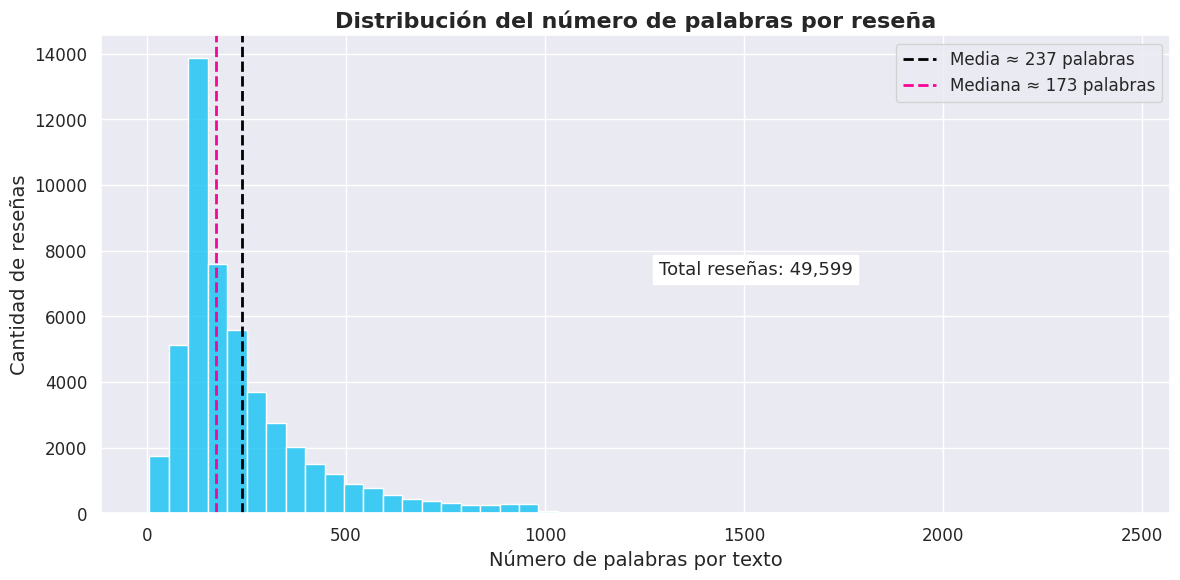

In [30]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      datos['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(datos):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

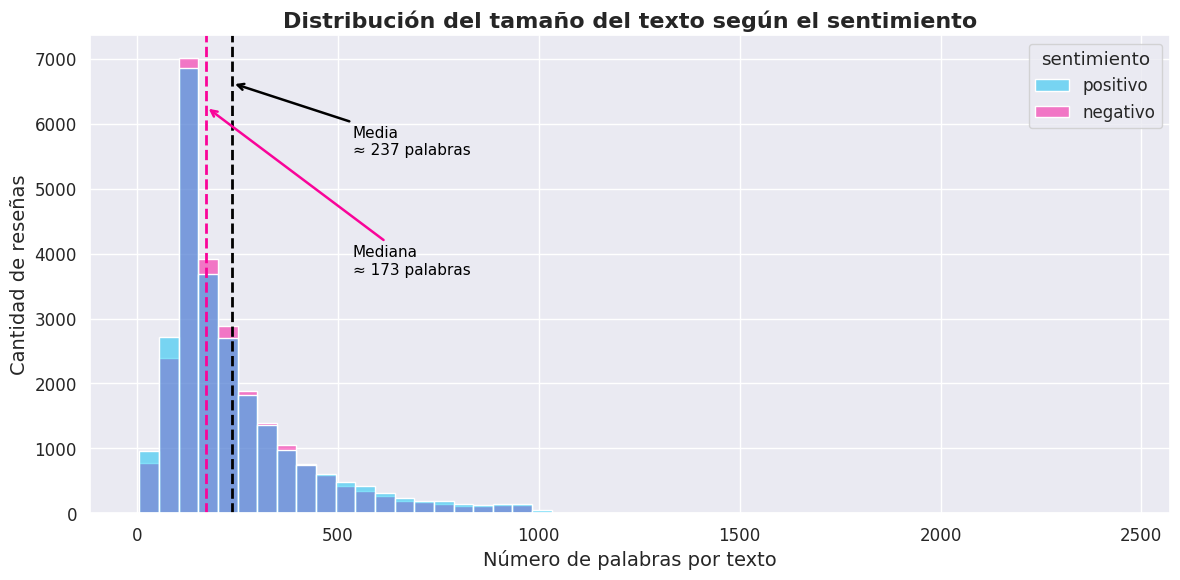

In [31]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = datos,
      x = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario],
      bins=50
  )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  ax.axvline(
      mediana,
      color = color_secundario,
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = color_secundario,
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

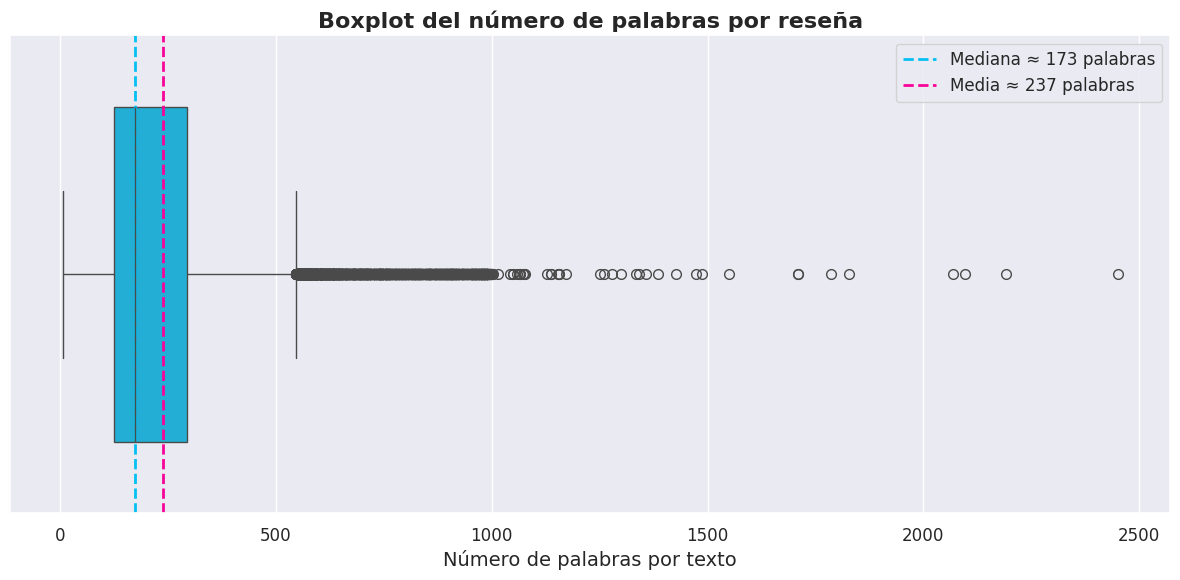

In [32]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = datos['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = datos['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

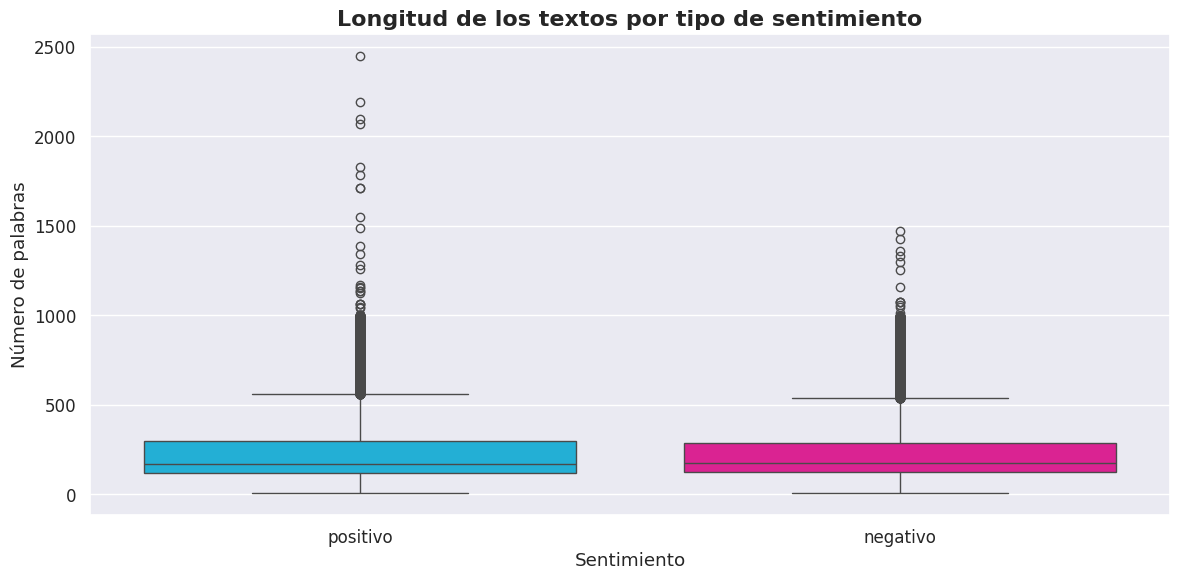

In [33]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = datos,
      x='sentimiento',
      y = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

* El conjunto de datos presenta algunos registros duplicados pero pocos comparados a la cantidad de datos, lo que indica una buena calidad inicial, además de que con la limpieza se eliminan para evitar sesgos por repetición de observaciones durante el entrenamiento del modelo.

* Las columnas cuentan con tipos de datos adecuados para el análisis, permitiendo trabajar correctamente con texto y variables categóricas.

#### **Conclusiones sobre la longitud de los textos**

- La longitud de las reseñas presenta alta variabilidad, con una media aproximada de 237 palabras y valores extremos que alcanzan más de 2400 palabras.

- La diferencia entre media y mediana indica una distribución sesgada a la derecha, confirmada por la presencia de múltiples outliers visibles en el boxplot.

- La mayoría de los textos se concentra en rangos bajos y medios de longitud, mientras que un pequeño porcentaje de reseñas muy extensas genera una cola larga en la distribución.

#### **Conclusiones sobre el idioma de los datos**

- Se detectó la presencia de reseñas en más de un idioma (español e inglés) dentro de la columna utilizada para el entrenamiento.

- Esto introduce un posible ruido lingüístico, ya que TF-IDF tratará palabras de ambos idiomas como parte del mismo vocabulario.

#### **Conclusión general del EDA**

El análisis exploratorio confirma que el conjunto de datos es apto para entrenar un modelo de análisis de sentimiento, cumpliendo con los requisitos del MVP propuesto.

Si bien existen desafíos como la alta variabilidad en la longitud de los textos y la presencia de múltiples idiomas, estos no impiden la construcción de un modelo inicial basado en TF-IDF y regresión logística.

El EDA permite identificar claramente oportunidades de mejora que pueden abordarse en iteraciones futuras, alineándose con el enfoque incremental esperado.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [34]:
datos.isnull().sum()

,0
review_es,0
sentimiento,0
n_palabras,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [35]:
def detectar_idioma(texto):
    try:
        return detect(texto) #Se usa la biblioteca langdetect
    except:
        return "desconocido"

In [36]:
datos.shape

(49599, 3)

In [37]:
#Columna con el idioma de la reseña (El procesamiento tardará)
datos['idioma_detectado'] = datos['review_es'].apply(detectar_idioma)

In [38]:
datos_limpios = datos[datos['idioma_detectado'] == 'es'].copy() #Solo guarda los datos en español

In [39]:
filas_originales = len(datos)
filas_limpias = len(datos_limpios)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 1815 filas que no estaban en español


In [40]:
datos = datos_limpios

In [41]:
datos.shape

(47784, 4)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [42]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23935
negativo,23849


In [43]:
print("\nEstadísticas de longitud antes del balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23935.0  230.686693  166.550784  10.0  122.0  170.0  290.0  955.0


#### Eliminar las reseñas más grandes (partes del sesgo) para mantener el equilibrio en el número de reseñas de ambos sentimientos

In [44]:
datos_pos = datos[datos['sentimiento'] == 'positivo'].copy()
datos_neg = datos[datos['sentimiento'] == 'negativo'].copy()

In [45]:
diferencia = len(datos_pos) - len(datos_neg)
print(f"Hay {diferencia} reseñas positivas extras")

Hay 86 reseñas positivas extras


In [46]:
datos_pos_balanceado = datos_pos.sort_values(by='n_palabras', ascending=False).iloc[diferencia:]
len(datos_pos_balanceado)

23849

In [47]:
datos_equilibrados = pd.concat([datos_pos_balanceado, datos_neg])

In [48]:
datos = shuffle(datos_equilibrados, random_state=42).reset_index(drop=True)

In [49]:
datos['sentimiento'].value_counts()

,count
sentimiento,
negativo,23849
positivo,23849


In [50]:
print("\nEstadísticas de longitud tras el balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud tras el balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23849.0  228.243406  161.791663  10.0  121.0  169.0  289.0  883.0


#### Estandarización a minúsculas

In [51]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es
...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es


In [52]:
datos['review_es_limpio'] = datos['review_es'].str.lower()

In [53]:
datos['review_es_limpio']

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,"¿nunca debo ir a este hospital [o hospicio, si..."
2,"alan rudolph es un director tan así, sin ese t..."
3,alquilé esto pensando que sería bastante bueno...
4,"la serie azul planet es, sin lugar a dudas, un..."
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...
47695,"oh hombre, ¿esta película alguna vez muerde!si..."
47696,"sin duda, una de las grandes obras maestras de..."


#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [54]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)


In [55]:
display(datos['review_es_limpio'])

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguo...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

In [56]:
# Reduce repeticiones excesivas de caracteres:
# Ej: "bueeeno" → "bueeno", "holaaaa" → "holaa"
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(
    r'(.)\1{2,}', r'\1\1', regex=True
)

Se decidió normalizar las secuencias de un mismo carácter repetido
3 o más veces, reduciéndolas a un máximo de 2 repeticiones.

Esta decisión permite:
- Reducir la variabilidad innecesaria del vocabulario
- Conservar parte de la intención emocional del texto
- Mejorar la calidad del texto para tareas de NLP como análisis de sentimiento

La normalización de caracteres repetidos se aplica para evitar que variaciones
ortográficas no semánticas afecten la tokenización y el desempeño del modelo.
Se conserva un máximo de dos repeticiones para no eliminar completamente
el énfasis expresivo del lenguaje informal.

#### Eliminar espacios múltiples

In [57]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [58]:
display(datos['review_es_limpio'])

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguos ...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [59]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado,review_es_limpio
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es,me derrota absolutamente por qué godard se tom...
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es,nunca debo ir a este hospital o hospicio si qu...
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es,alan rudolph es un director tan así sin ese to...
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es,alquilé esto pensando que sería bastante bueno...
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es,la serie azul planet es sin lugar a dudas uno ...
...,...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es,minutos de esto es cruel y amo a los antiguos ...
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es,oh hombre esta película alguna vez muerdesi al...
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es,sin duda una de las grandes obras maestras de ...


### **Definición de variables de entrada (X) y salida (y)**

In [60]:
X = datos['review_es_limpio']

In [61]:
display(X)

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguos ...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


In [62]:
y = datos['sentimiento'].map({
    'negativo': 0,
    'positivo': 1
})

In [63]:
display(y)

,sentimiento
0,0
1,1
2,0
3,0
4,1
...,...
47693,1
47694,0
47695,0
47696,1


### **División de datos en conjuntos de entrenamiento y prueba**

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [526]:
stopwords_es = set(stopwords.words('spanish'))

In [528]:
palabras_vitales = {'no', 'ni', 'sin', 'pero', 'nunca', 'jamás', 'tampoco', 'es', 'esta', 'está', 'fue', 'era', 'son', 'ser'}

In [530]:
stopwords_final = [w for w in stopwords_es if w not in palabras_vitales]

In [68]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_personalizadas,
    ngram_range = (1, 3),
    max_features = 25_000,
    strip_accents='unicode',
    min_df = 5,
    max_df = 0.9,
    sublinear_tf = True
)

In [531]:
print(f"¿'no' es stopword?: {'no' in stopwords_final}") # Debe ser False
print(f"¿'la' es stopword?: {'la' in stopwords_final}") # Debe ser True

¿'no' es stopword?: False
¿'la' es stopword?: True


stop_words=stopwords_personalizadas
Se usan stopwords en español, pero se conservan negaciones como “no”, “pero”, “sin” para no perder información semántica clave en el sentimiento.

- g`ram_range=(1, 2)`
Incluye unigramas y bigramas para capturar tanto palabras individuales como expresiones relevantes (“no me gustó”, “muy buena”).

- `max_features=5000`
Limita el vocabulario a los términos más informativos, logrando un buen balance entre rendimiento y costo computacional.

- `min_df=5`
Elimina términos muy poco frecuentes, reduciendo ruido y aumentando la estabilidad del modelo.

- `max_df=0.9`
Excluye palabras demasiado comunes que no ayudan a diferenciar el sentimiento.

- `sublinear_tf=True`
Reduce el impacto de repeticiones excesivas de una palabra, evitando que dominen la representación del texto.

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [69]:
X_train_tfidf  = vectorizador.fit_transform(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'teniamos', 'tenian', 'tenias', 'tuvie

In [70]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3661758 stored elements and shape (33388, 25000)>

### **Transformación del conjunto de prueba**

In [71]:
X_test_tfidf = vectorizador.transform(X_test)

In [72]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1543235 stored elements and shape (14310, 25000)>

#### Dimension

In [73]:
X_train_tfidf.shape

(33388, 25000)

In [74]:
X_test_tfidf.shape

(14310, 25000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [75]:
modelo = LogisticRegression(
    random_state = 42,
    max_iter = 1000,
    class_weight = 'balanced',
    solver = 'liblinear'
    )

Se utiliza Regresión Logística para la clasificación de sentimiento debido a su estabilidad, buen desempeño con texto vectorizado mediante TF-IDF y capacidad de devolver probabilidades, requisito clave para la API.


- `max_iter=1000`
Aumenta el número máximo de iteraciones para asegurar que el modelo tenga suficiente tiempo para converger correctamente, especialmente al trabajar con un gran número de características generadas por TF-IDF.

- `class_weight='balanced'`
Ajusta automáticamente el peso de cada clase, haciendo el modelo más robusto ante posibles desbalances y evitando sesgos en la predicción.

- `solver='liblinear'`
Selecciona un método de optimización estable y eficiente, especialmente adecuado para problemas de clasificación binaria con conjuntos de datos de tamaño medio y alta dimensionalidad.

#### Entrenamiento del modelo

In [76]:
modelo.fit(X_train_tfidf, y_train, )

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

#### Predicciones

In [77]:
y_pred = modelo.predict(X_test_tfidf)

In [78]:
y_proba = modelo.predict_proba(X_test_tfidf)

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [79]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['negativo', 'positivo']))


Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.90      0.87      0.88      7155
    positivo       0.87      0.90      0.89      7155

    accuracy                           0.88     14310
   macro avg       0.88      0.88      0.88     14310
weighted avg       0.88      0.88      0.88     14310



#### Obtener palabras más significativas para cada sentimiento

In [80]:
palabras = vectorizador.get_feature_names_out()
coefs = modelo.coef_.flatten()
datos_palabras = pd.DataFrame({'palabra': palabras, 'coeficiente': coefs})

In [81]:
top_pos = datos_palabras.nlargest(10, 'coeficiente')
top_neg = datos_palabras.nsmallest(10, 'coeficiente')
top_palabras = pd.concat([top_pos, top_neg])

/tmp/ipython-input-3743336128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')


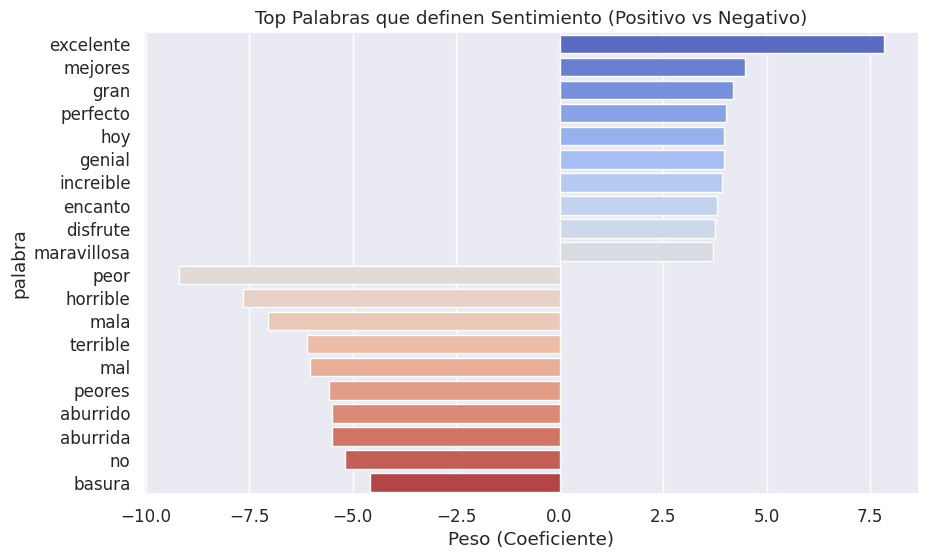

In [82]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')
plt.title('Top Palabras que definen Sentimiento (Positivo vs Negativo)')
plt.xlabel('Peso (Coeficiente)')
plt.show()

#### Análisis de Errores


In [83]:
datos_test = X_test.to_frame(name='review').copy()
datos_test['real'] = y_test
datos_test['prediccion'] = y_pred

In [84]:
errores = datos_test[datos_test['real'] != datos_test['prediccion']]
print(f"Total de errores: {len(errores)} de {len(datos_test)}")

Total de errores: 1653 de 14310


In [85]:
errores.sample(10)

,review,real,prediccion
21840,todavía puedo recordar primero ver esto en la ...,1,0
29032,bueno esta fue mi primera experiencia imax así...,0,1
29092,no es la película más divertida de todos los t...,0,1
2983,es una buena película si planeas ver muchos pa...,0,1
13258,le di un solo siete porque la actuación es bue...,1,0
2266,he visto unas pocas películas justas del lejan...,1,0
42015,por lo que puedo decirle a pesar de los coment...,0,1
36090,diana guzmán es una joven enojada sobreviviend...,0,1
11976,tras el consejo de un amigo me conseguí esta p...,1,0
24974,no hay otra palabra para eso fox dejó esto sin...,1,0


##### Falsos Positivos (Eran negativos y se clasificaron como positivos)

Son los errores más importantes y que se tienen que destacar, dado que en los requisitos (y en general para cualquier modelo de atención al cliente) es peor ignorar los comentarios negativos y no darles atención (falsos positivos)

In [86]:
for i, row in errores[errores['prediccion'] == 1].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: si el término en sí no era geográfico y semánticamente sin sentido uno podría consultar ned kelly como western australiano para la gente abajo ned kelly estaba aparentemente un bandido de héroe popular similar a robin hood jesse james bonnie y clyde y butch cassidy y el niño sundance el descendiente...
Real: 0 | Pred: 1

Review: alquilé esta película porque esperaba que fuera uno toda la familia disfruteaunque la película es amigable para la familia mi familia no lo disfrutó porque da una visión falsa de diossi obedeces a dios y lo sigue no tienes éxito garantizadotu equipo de fútbol no siempre ganaráno te pondrás mágicamen...
Real: 0 | Pred: 1

Review: soy una gran marca para la música de neil young y con eso y el alabado brillante la película recibió en muchos círculos de prensa altindie golpeó la primera muestra de greendale que pude encontrar mi emoción fue de corta duración ya que esta historia turgida y el débil momento lírico dejó a la mayor...
Real: 0 | Pred: 1



##### Falsos Negativos (Eran positivos y se clasificaron como negativos)

In [87]:
for i, row in errores[errores['prediccion'] == 0].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: tenía años cuando este espectáculo estaba en la televisiónde lejos fue mi favoritolos actores eran muy creíblesalexandra bastedo era simplemente magnífico solo pido el dvd episodiosno tenían superpoderessolo tenían habilidades humanas superiores fuerza audición vistalos actores eran muy buenos en su...
Real: 1 | Pred: 0

Review: se divirtió viendo esta película a pesar de la sensación de que obtuve mucho tiempo que esta película estaba casi copiando a monsters inc hay bastantes cosas que son extremadamente similares entre las dos la relación entre un animal monstruo yun niño pequeño otros animales que intentan romper esa re...
Real: 1 | Pred: 0

Review: este fue uno de los peores episodios de columbo que he visto sin embargo estoy solo en la segunda temporada las actividades típicas de columbo son divertidas e irritantessus cenicientas que le causan problemas se han visto antes y el mío donde siempre se identifica de alguna manera con el asesino en...
Real: 1 | Pred: 0



#### Matriz de confusión


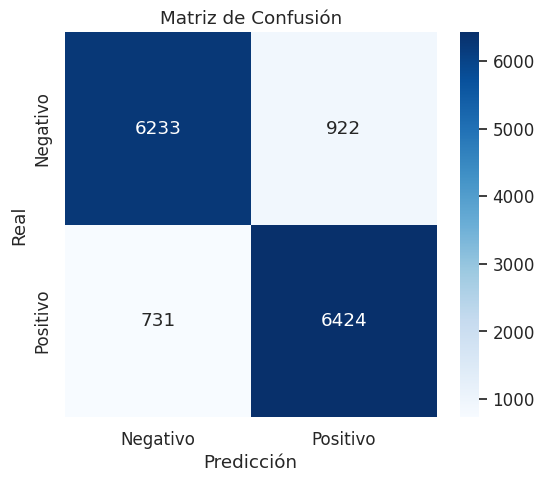

In [88]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

La matriz de confusión muestra como hay un poco más de falsos positivos que de falsos negativos, para este ejemplo, nos importa mucho más las reseñas negativas para poder atender el disgusto de los clientes. Por lo tanto, es preferible tener menos falsos positivos (reseñas negativas tomadas como positivas) aunque eso conlleve a tener un poco más de falsos negativos.

#### Obtener el mejor umbral para reducir falsos positivos

In [397]:
# Mejores parametros encontados hasta el momento
"""
pipeline_test = Pipeline([

    ('tfidf', TfidfVectorizer(

        stop_words = stopwords_personalizadas,

        ngram_range = (1, 3),

        max_features = 25_000,

        min_df = 2,

        max_df = 0.9,

        sublinear_tf = True

        )),

         ('clf', LogisticRegression(

             C = 10,

             random_state = 42,

             max_iter = 1000,

             class_weight = 'balanced',

             solver = 'liblinear'

             ))

         ])



pipeline_test.fit(X, y)
"""

In [ ]:
pipeline_test = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words = stopwords_final,
        ngram_range = (1, 3),
        max_features = 40_000,
        min_df = 5,
        max_df = 0.7,
        sublinear_tf = True
        )),
         ('clf', LogisticRegression(
             C = 1.0,
             random_state = 42,
             max_iter = 1000,
             class_weight = 'balanced',
             solver = 'liblinear'
             ))
         ])

pipeline_test.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.7, max_features=40000, min_df=5,
                                 ngram_range=(1, 3),
                                 stop_words=['ante', 'fueses', 'sentida',
                                             'estarás', 'fueran', 'el', 'te',
                                             'suyo', 'esto', 'estos',
                                             'seríamos', 'fueras', 'tenidas',
                                             'fuésemos', 'estabas', 'cual',
                                             'vuestras', 'tuviésemos', 'tienes',
                                             'tendrías', 'haya', 'todos',
                                             'hayáis', 'tenéis', 'estuviesen',
                                             'sean', 'nos', 'tened', 'estás',
                                             'habrías', ...],
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])

In [547]:
probs = pipeline_test.predict_proba(X_test)[:, 1]

In [548]:
def probar_umbral(umbral):
    # Si la probabilidad es mayor al umbral, es 'positivo', si no 'negativo'
    preds_ajustadas = np.where(probs > umbral, 1, 0)

    # Generar matriz de confusión con el nuevo umbral
    cm = confusion_matrix(y_test, preds_ajustadas, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return fp, fn, cm

In [549]:
umbrales = [
    0.40,
    0.45,
    0.50,
    0.55,
    0.58,
    0.60,
    0.61,
    0.62,
    0.63,
    0.635,
    0.64,
    0.645,
    0.65,
    0.655,
    0.66,
    0.665,
    0.67,
    0.675,
    0.68,
    0.69,
    0.70,
    0.75,
    0.80
]

In [550]:
print(f"{'Umbral':<10} {'Falsos Positivos (Riesgo)':<25} {'Falsos Negativos (Revisión extra)'}")
print("-" * 70)
for u in umbrales:
    fp, fn, _ = probar_umbral(u)
    print(f"{u:<10} {fp:<25} {fn}")

Umbral     Falsos Positivos (Riesgo) Falsos Negativos (Revisión extra)
----------------------------------------------------------------------
0.4        987                       185
0.45       718                       277
0.5        509                       431
0.55       356                       590
0.58       285                       710
0.6        235                       829
0.61       220                       889
0.62       199                       946
0.63       185                       1003
0.635      179                       1040
0.64       173                       1072
0.645      167                       1099
0.65       160                       1133
0.655      157                       1165
0.66       153                       1203
0.665      147                       1250
0.67       137                       1292
0.675      129                       1333
0.68       121                       1373
0.69       115                       1447
0.7        105            

#### Usando el mejor umbral

Al tener un umbral más alto, es más estricto para que el modelo clasifique una reseña como positiva, lo que reduce significativamente la probabilidad de no atender una reseña negativa.

El mejor umbral fue de ***0.65***, con lo que se reducen la cantidad de falsos positivos, pero sin llevar a una enorme cantidad de falsos negativos.
Considerando los requisitos del proyecto, es priorizable detectar correctamente las reseñas negativas que las positivas.

In [551]:
mejor_umbral = 0.51
y_pred_final = np.where(probs > mejor_umbral, 1, 0)


--- Matriz de Confusión con Umbral 0.51 ---


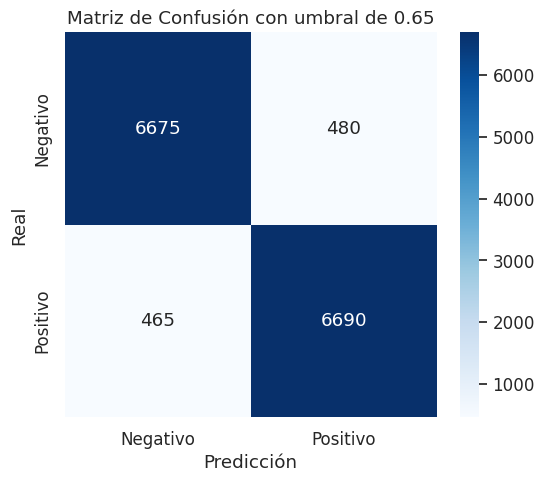

In [552]:
print(f"\n--- Matriz de Confusión con Umbral {mejor_umbral} ---")
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión con umbral de 0.65')
plt.show()

In [553]:
# Simulación de predicción
texto_ejemplo = "No excelente"

In [554]:
pred_sentimiento = pipeline_test.predict([texto_ejemplo])

In [555]:
probabilidades = pipeline_test.predict_proba([texto_ejemplo])

In [556]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [557]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [1], Probabilidad: 1.00


In [472]:
# Score en entrenamiento
train_score = pipeline_test.score(X_train, y_train)
# Score en prueba
test_score = pipeline_test.score(X_test, y_test)

print(f"Precisión Entrenamiento: {train_score:.4f}")
print(f"Precisión Prueba: {test_score:.4f}")
print(f"Diferencia: {train_score - test_score:.4f}")

Precisión Entrenamiento: 0.9776
Precisión Prueba: 0.9799
Diferencia: -0.0024


In [473]:
from sklearn.model_selection import cross_val_score

# Usamos 5 carpetas (folds)
scores = cross_val_score(pipeline_test, X, y, cv=5)

print(f"Scores de cada carpeta: {scores}")
print(f"Promedio: {scores.mean():.4f}")
print(f"Desviación Estándar: {scores.std():.4f}") # Si es alta, el modelo es inestable

Scores de cada carpeta: [0.89549266 0.88689727 0.89318658 0.88856274 0.8961107 ]
Promedio: 0.8920
Desviación Estándar: 0.0037


Pesos del modelo

In [494]:
# Busca los pesos de las palabras clave
vocab = pipeline_test.named_steps['tfidf'].vocabulary_
coefs = pipeline_test.named_steps['clf'].coef_[0]
features = pipeline_test.named_steps['tfidf'].get_feature_names_out()

palabras = ['no', 'excelente', 'no excelente', 'malo']
for p in palabras:
    if p in vocab:
        idx = vocab[p]
        print(f"Token: {p:<15} | Peso: {coefs[idx]:.4f}")
    else:
        print(f"Token: {p:<15} | No está en el vocabulario")

Token: no              | No está en el vocabulario
Token: excelente       | Peso: 10.8969
Token: no excelente    | No está en el vocabulario
Token: malo            | Peso: -4.5902


## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el Back-End pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [96]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words = stopwords_personalizadas,
        strip_accents='unicode',
        ngram_range = (1, 2),
        max_features = 5000,
        min_df = 5,
        max_df = 0.9,
        sublinear_tf = True
        )),
        ('clf', LogisticRegression(
        random_state = 42,
        max_iter = 1000,
        class_weight = 'balanced',
        solver = 'liblinear'
        ))
    ])

### **Reentrenar el pipeline con X y Y**

In [ ]:
pipeline_final.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'teniamos', 'tenian', 'tenias', 'tuvie

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['ante', 'fueses', 'sentida',
                                             'estemos', 'estarás', 'fueran',
                                             'vosotras', 'y', 'habías',
                                             'hubiesen', 'tendrán', 'fue',
                                             'habrán', 'los', 'había', 'el',
                                             'te', 'vuestra', 'suyo', 'esto',
                                             'está', 'estos', 'fuese',
                                             'seríamos', 'fueras', 'hubierais',
                                             'tenidas', 'serán', 'ellas',
                                             'fuésemos', ...],
                                 strip_accents='unicode', sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])

### **Serialización**

In [98]:
joblib.dump(pipeline_final, 'sentiment_model_1.4.joblib')

['sentiment_model_1.4.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [99]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [100]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [101]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [102]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [103]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [0], Probabilidad: 0.59


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

~~~
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}

~~~

**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

### Archivo requirements.txt
### Dentro del archivo .txt el siguiente texto:

- fastapi
- uvicorn
- joblib
- scikit-learn
- nltk
- numpy

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. cd data_science
- 2. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 3. Encender el servidor: uvicorn app:app --reload

### Arhivo ipynb, Modelo_hackathon.ipynb
El archivo .ipynb crea el archivo (sentiment_model.joblib)
Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): `pip install -r requirements.txt`
- 2. Encender el servidor: `uvicorn app:app --reload`